# Построение линейной регрессии

## Датасет
В работе используется датасет Diabetes из библиотеки sklearn.
Он содержит медицинские данные пациентов и применяется для задачи регрессии, то есть для предсказания числового значения.

В датасете:

-	442 объекта — это пациенты,
-	10 признаков — характеристики пациентов,
-	целевая переменная — числовой показатель, количественная мера прогрессирования заболевания через год.

| Признак | Краткое описание |
|---|---|
| age | возраст |
| sex | пол |
| bmi | индекс массы тела |
| bp | артериальное давление |
| s1 | показатель, связанный с сывороткой крови |
| s2 | сывороточный показатель |
| s3 | биохимический показатель |
| s4 | биохимический показатель |
| s5 | биохимический показатель |
| s6 | биохимический показатель |


## Используемые библиотеки

В работе используются `numpy`, `pandas`, `matplotlib` и инструменты `sklearn` для загрузки датасета, обучения линейной регрессии и расчёта метрик


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
diabetes = load_diabetes()

print("Названия признаков:")
print(diabetes.feature_names)

Названия признаков:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [4]:
X = diabetes.data
y = diabetes.target

print("\nРазмер X:", X.shape)
print("Размер y:", y.shape)

feature_index = diabetes.feature_names.index("bmi")
X_single = X[:, feature_index].reshape(-1, 1)

print("\nРазмер X_single:", X_single.shape)


Размер X: (442, 10)
Размер y: (442,)

Размер X_single: (442, 1)


## Предварительная обработка датасета

Проверяем форму данных, отсутствие пропусков и создаём `DataFrame` для дальнейшего анализа признаков


In [5]:
df_diabetes = pd.DataFrame(X, columns=diabetes.feature_names)

print('Первые 5 строк датасета:')
display(df_diabetes.head())
print(f'Пропусков в признаках: {int(df_diabetes.isna().sum().sum())}')
print(f'Дубликатов строк:      {int(df_diabetes.duplicated().sum())}')
print(f'Используемый признак для модели: bmi (индекс {feature_index})')


Первые 5 строк датасета:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


Пропусков в признаках: 0
Дубликатов строк:      0
Используемый признак для модели: bmi (индекс 2)


## Тепловая карта

Строим тепловую карту корреляций между признаками датасета `Diabetes`


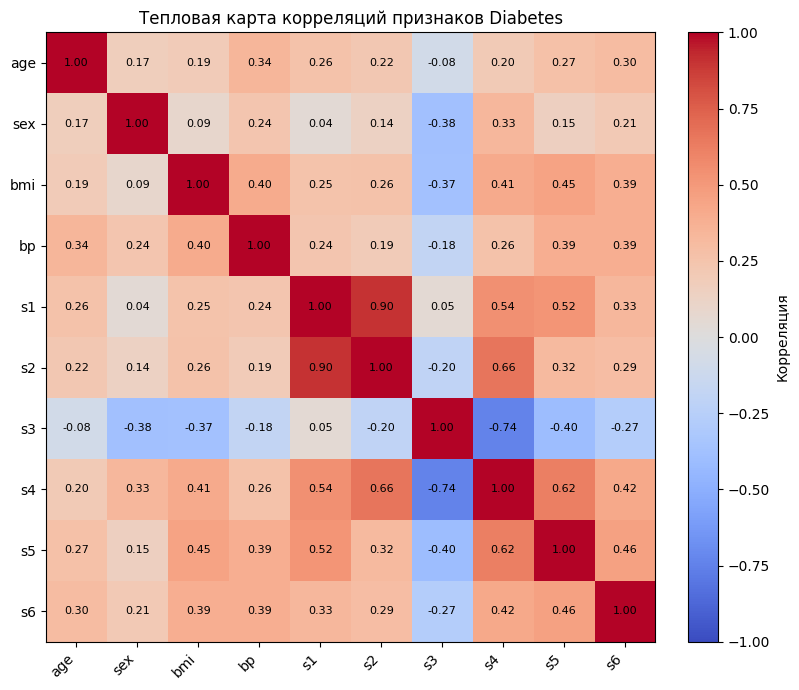

In [6]:
heatmap_features = list(diabetes.feature_names)
if len(heatmap_features) > 12:
    heatmap_features = heatmap_features[:12]

corr_matrix = df_diabetes[heatmap_features].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_features)))
ax.set_yticks(range(len(heatmap_features)))
ax.set_xticklabels(heatmap_features, rotation=45, ha='right')
ax.set_yticklabels(heatmap_features)
ax.set_title('Тепловая карта корреляций признаков Diabetes')

for i in range(len(heatmap_features)):
    for j in range(len(heatmap_features)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha='center', va='center', color='black', fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Корреляция')
plt.tight_layout()
plt.show()


## Графики выходных результатов

Сначала визуализируем исходную зависимость целевой переменной от признака `BMI`


## Визуализация зависимости целевой переменной от признака BMI

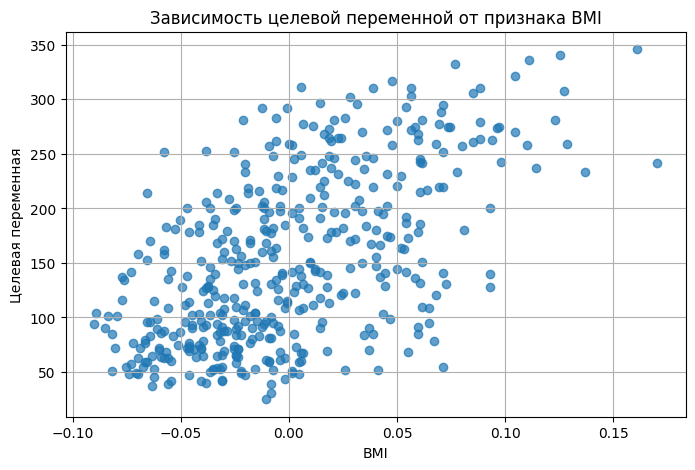

Размер обучающей выборки: 353
Размер тестовой выборки: 89


In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(X_single, y, alpha=0.7)
plt.title("Зависимость целевой переменной от признака BMI")
plt.xlabel("BMI")
plt.ylabel("Целевая переменная")
plt.grid(True)
plt.show()

# Делим данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_single, y, test_size=0.2, random_state=42
)

print("Размер обучающей выборки:", X_train.shape[0])
print("Размер тестовой выборки:", X_test.shape[0])

## Обучение

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

print("\nКоэффициент наклона (k):", model.coef_[0])
print("Свободный член (b):", model.intercept_)


Коэффициент наклона (k): 998.5776891375593
Свободный член (b): 152.00335421448167


## Прогнозы модели

Сравниваем реальные значения с предсказаниями линейной регрессии


In [9]:
y_pred = model.predict(X_test)

print("\nПервые 10 реальных значений:")
print(y_test[:10])

print("\nПервые 10 предсказанных значений:")
print(y_pred[:10])


Первые 10 реальных значений:
[219.  70. 202. 230. 111.  84. 242. 272.  94.  96.]

Первые 10 предсказанных значений:
[145.80622687 188.85739048 147.95878505 203.92529774 131.8145987
 127.50948234 322.31599764 197.4676232   61.85645785 167.33180868]


In [10]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nМетрики качества модели:")
print("MAE  =", mae)
print("MSE  =", mse)
print("RMSE =", rmse)
print("R2   =", r2)


Метрики качества модели:
MAE  = 52.25997644534553
MSE  = 4061.8259284949268
RMSE = 63.73245584860925
R2   = 0.23335039815872138


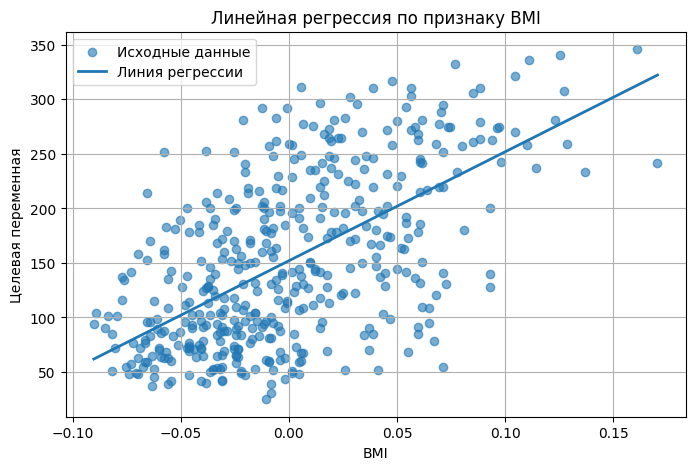

In [11]:
X_line = np.linspace(X_single.min(), X_single.max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)

plt.figure(figsize=(8, 5))
plt.scatter(X_single, y, alpha=0.6, label="Исходные данные")
plt.plot(X_line, y_line, linewidth=2, label="Линия регрессии")
plt.title("Линейная регрессия по признаку BMI")
plt.xlabel("BMI")
plt.ylabel("Целевая переменная")
plt.legend()
plt.grid(True)
plt.show()

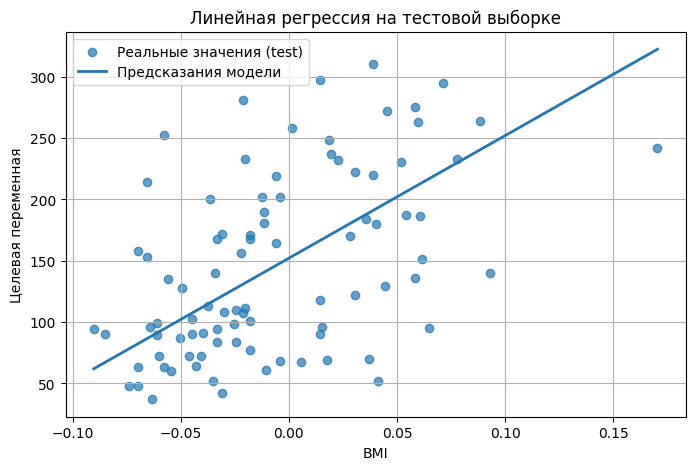

In [12]:
sorted_idx = np.argsort(X_test[:, 0])
X_test_sorted = X_test[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, alpha=0.7, label="Реальные значения (test)")
plt.plot(X_test_sorted, y_pred_sorted, linewidth=2, label="Предсказания модели")
plt.title("Линейная регрессия на тестовой выборке")
plt.xlabel("BMI")
plt.ylabel("Целевая переменная")
plt.legend()
plt.grid(True)
plt.show()